In [8]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [9]:
df = pd.read_csv("spotify_clean.csv")

In [10]:
df.shape

(113549, 20)

In [11]:
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

In [12]:
X = df[features]

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [14]:
knn = NearestNeighbors(
    n_neighbors=11,
    metric='cosine'
)

In [15]:
knn.fit(X_scaled)

,n_neighbors,11
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [16]:
song = "Shape of You"

df[df['track_name'] == song]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
80706,7qiZfU4dY1lWllzX7mPBI3,Ed Sheeran,÷ (Deluxe),Shape of You,86,233712,False,0.825,0.652,1,-3.183,0,0.0802,0.581,0.0,0.0931,0.931,95.977,4,pop


In [17]:
song_index = df[df['track_name'] == song].index[0]

In [18]:
distances, indices = knn.kneighbors(
    X_scaled[song_index].reshape(1,-1)
)

In [19]:
indices

array([[80706, 21509, 69618, 94961, 60425, 65883, 95073, 94719, 21768,
        21776, 21148]])

In [20]:
distances

array([[0.        , 0.02317838, 0.02335263, 0.02343789, 0.02420465,
        0.02505955, 0.02606519, 0.02765316, 0.02842983, 0.02940137,
        0.02985483]])

In [21]:
for i in range(1, len(indices[0])):

    index = indices[0][i]

    print(df.iloc[index]['track_name'])

Tene
Yaaro
Brujeria
Go-Go Club - Raw
Pop the Bubbles
Separemos Nuestras Vidas
Quiero Llenarte
Low
Pull Up
Whine It


In [22]:
for i in range(1, len(indices[0])):

    index = indices[0][i]

    print("Song :", df.iloc[index]['track_name'])

    print("Artist :", df.iloc[index]['artists'])

    print("-"*40)

Song : Tene
Artist : Larry Gaaga;Flavour
----------------------------------------
Song : Yaaro
Artist : Santesh;Amos Paul
----------------------------------------
Song : Brujeria
Artist : El Gran Combo De Puerto Rico
----------------------------------------
Song : Go-Go Club - Raw
Artist : Vybz Kartel
----------------------------------------
Song : Pop the Bubbles
Artist : Patty Shukla
----------------------------------------
Song : Separemos Nuestras Vidas
Artist : Jerry Rivera
----------------------------------------
Song : Quiero Llenarte
Artist : Jerry Rivera
----------------------------------------
Song : Low
Artist : Larry Gaaga;Wizkid
----------------------------------------
Song : Pull Up
Artist : Timaya;Burna Boy
----------------------------------------
Song : Whine It
Artist : Jahyanai;Timal
----------------------------------------


In [23]:
for i in range(1, len(indices[0])):

    index = indices[0][i]

    print("Song :", df.iloc[index]['track_name'])

    print("Artist :", df.iloc[index]['artists'])

    print("Distance :", distances[0][i])

    print("-"*40)

Song : Tene
Artist : Larry Gaaga;Flavour
Distance : 0.0231783780073197
----------------------------------------
Song : Yaaro
Artist : Santesh;Amos Paul
Distance : 0.023352634293911323
----------------------------------------
Song : Brujeria
Artist : El Gran Combo De Puerto Rico
Distance : 0.02343789364529658
----------------------------------------
Song : Go-Go Club - Raw
Artist : Vybz Kartel
Distance : 0.0242046464641833
----------------------------------------
Song : Pop the Bubbles
Artist : Patty Shukla
Distance : 0.02505955466789711
----------------------------------------
Song : Separemos Nuestras Vidas
Artist : Jerry Rivera
Distance : 0.026065192142867954
----------------------------------------
Song : Quiero Llenarte
Artist : Jerry Rivera
Distance : 0.027653163414705917
----------------------------------------
Song : Low
Artist : Larry Gaaga;Wizkid
Distance : 0.0284298278027717
----------------------------------------
Song : Pull Up
Artist : Timaya;Burna Boy
Distance : 0.0294013

In [24]:
def recommend_song(song_name):

    # Check if song exists
    if song_name not in df['track_name'].values:

        print("Song not found!")

        return

    # Get song index
    song_index = df[df['track_name'] == song_name].index[0]

    # Find nearest songs
    distances, indices = knn.kneighbors(
        X_scaled[song_index].reshape(1,-1)
    )

    print("="*60)

    print("Recommendations for:", song_name)

    print("="*60)

    for i in range(1,len(indices[0])):

        index = indices[0][i]

        print(f"Song : {df.iloc[index]['track_name']}")

        print(f"Artist : {df.iloc[index]['artists']}")

        print(f"Genre : {df.iloc[index]['track_genre']}")

        print(f"Distance : {distances[0][i]:.3f}")

        print("-"*60)

In [25]:
recommend_song("Shape of You")

Recommendations for: Shape of You
Song : Tene
Artist : Larry Gaaga;Flavour
Genre : dancehall
Distance : 0.023
------------------------------------------------------------
Song : Yaaro
Artist : Santesh;Amos Paul
Genre : malay
Distance : 0.023
------------------------------------------------------------
Song : Brujeria
Artist : El Gran Combo De Puerto Rico
Genre : salsa
Distance : 0.023
------------------------------------------------------------
Song : Go-Go Club - Raw
Artist : Vybz Kartel
Genre : j-dance
Distance : 0.024
------------------------------------------------------------
Song : Pop the Bubbles
Artist : Patty Shukla
Genre : kids
Distance : 0.025
------------------------------------------------------------
Song : Separemos Nuestras Vidas
Artist : Jerry Rivera
Genre : salsa
Distance : 0.026
------------------------------------------------------------
Song : Quiero Llenarte
Artist : Jerry Rivera
Genre : salsa
Distance : 0.028
------------------------------------------------------

In [26]:
duplicate_songs = df['track_name'].value_counts()

duplicate_songs[duplicate_songs > 1].head(10)

track_name
Run Rudolph Run                   151
Halloween                          88
Frosty The Snowman                 80
Little Saint Nick - 1991 Remix     74
Christmas Time                     72
Last Last                          70
CÓMO SE SIENTE - Remix             64
Sleigh Ride                        61
RUMBATÓN                           57
X ÚLTIMA VEZ                       57
Name: count, dtype: int64

In [27]:
def search_song(keyword):

    result = df[df['track_name'].str.contains(keyword, case=False, na=False)]

    return result[['track_name', 'artists', 'track_genre']]

In [28]:
search_song("shape")

,track_name,artists,track_genre
2257,Heart-Shaped Box,Nirvana,alt-rock
3365,Heart-Shaped Box,Nirvana,alternative
6259,He Who Mastered Shapes,Imperialist,black-metal
15612,cloud shapes,chief.,chill
17387,Shape Shifter,3FORCE,club
24271,Master of All Visible Shapes,Surgeon,detroit-techno
24590,Shaper of the Unknown,Surgeon,detroit-techno
27104,Buss A Lickle Shape,Benny Page;Sweetie Irie,drum-and-bass
27217,Barricades (with Rita Ora) - Shapes Remix,Netsky;Rita Ora;Shapes,drum-and-bass
31257,Shapeshifter,Alessia Cara,electro


In [29]:
df['song_artist'] = (
    df['track_name'] +
    " - " +
    df['artists']
)

In [30]:
df[['song_artist']].head()

,song_artist
0,Comedy - Gen Hoshino
1,Ghost - Acoustic - Ben Woodward
2,To Begin Again - Ingrid Michaelson;ZAYN
3,Can't Help Falling In Love - Kina Grannis
4,Hold On - Chord Overstreet


In [31]:
def recommend_song(song_name):

    # Find matching songs
    matches = df[df['track_name'].str.lower() == song_name.lower()]

    if matches.empty:
        print("Song not found!")
        return

    # Use the first matching song
    song_index = matches.index[0]

    distances, indices = knn.kneighbors(
        X_scaled[song_index].reshape(1, -1)
    )

    print("=" * 60)
    print("Recommendations")
    print("=" * 60)

    for i in range(1, len(indices[0])):

        idx = indices[0][i]

        print(f"Song   : {df.iloc[idx]['track_name']}")
        print(f"Artist : {df.iloc[idx]['artists']}")
        print(f"Genre  : {df.iloc[idx]['track_genre']}")
        print(f"Distance : {distances[0][i]:.4f}")
        print("-" * 60)

In [32]:
def recommend_song_artist(song, artist):

    result = df[
        (df['track_name'].str.lower() == song.lower()) &
        (df['artists'].str.lower() == artist.lower())
    ]

    if result.empty:
        print("Song not found!")
        return

    index = result.index[0]

    distances, indices = knn.kneighbors(
        X_scaled[index].reshape(1, -1)
    )

    print(f"\nRecommendations for {song} - {artist}\n")

    for i in range(1, len(indices[0])):

        idx = indices[0][i]

        print(df.iloc[idx]['track_name'], "-", df.iloc[idx]['artists'])

In [33]:
def search_song(keyword):

    result = df[df['track_name'].str.contains(keyword, case=False, na=False)]

    return result[
        [
            'track_name',
            'artists',
            'album_name',
            'track_genre'
        ]
    ].head(20)

In [34]:
def search_artist(artist):

    return df[
        df['artists'].str.contains(
            artist,
            case=False,
            na=False
        )
    ][
        [
            'track_name',
            'artists',
            'track_genre'
        ]
    ].head(20)

In [35]:
def recommend_genre(genre):

    songs = df[
        df['track_genre'].str.lower() == genre.lower()
    ]

    return songs[
        [
            'track_name',
            'artists',
            'popularity'
        ]
    ].sort_values(
        by='popularity',
        ascending=False
    ).head(10)

In [36]:
def trending_songs(top_n=10):

    return df[
        [
            'track_name',
            'artists',
            'popularity'
        ]
    ].sort_values(
        by='popularity',
        ascending=False
    ).head(top_n)

In [37]:
df[['valence','energy','danceability']].describe()

,valence,energy,danceability
count,113549.000000,113549.000000,113549.000000
mean,0.474205,0.642091,0.567031
std,0.259204,0.251053,0.173409
min,0.000000,0.000000,0.000000
25%,0.260000,0.473000,0.456000
50%,0.464000,0.685000,0.580000
75%,0.683000,0.854000,0.695000
max,0.995000,1.000000,0.985000


In [38]:
def get_mood(row):

    if row['valence'] >= 0.7 and row['energy'] >= 0.6:
        return "Happy"

    elif row['valence'] <= 0.3 and row['energy'] <= 0.5:
        return "Sad"

    elif row['energy'] >= 0.8:
        return "Energetic"

    elif row['acousticness'] >= 0.7:
        return "Calm"

    else:
        return "Neutral"

In [39]:
df['mood'] = df.apply(get_mood, axis=1)

In [40]:
df[['track_name','artists','mood']].head(10)

,track_name,artists,mood
0,Comedy,Gen Hoshino,Neutral
1,Ghost - Acoustic,Ben Woodward,Sad
2,To Begin Again,Ingrid Michaelson;ZAYN,Sad
3,Can't Help Falling In Love,Kina Grannis,Sad
4,Hold On,Chord Overstreet,Sad
5,Days I Will Remember,Tyrone Wells,Neutral
6,Say Something,A Great Big World;Christina Aguilera,Sad
7,I'm Yours,Jason Mraz,Neutral
8,Lucky,Jason Mraz;Colbie Caillat,Neutral
9,Hunger,Ross Copperman,Neutral


In [41]:
df['mood'].value_counts()

mood
Neutral      39973
Energetic    27336
Happy        20043
Sad          14700
Calm         11497
Name: count, dtype: int64

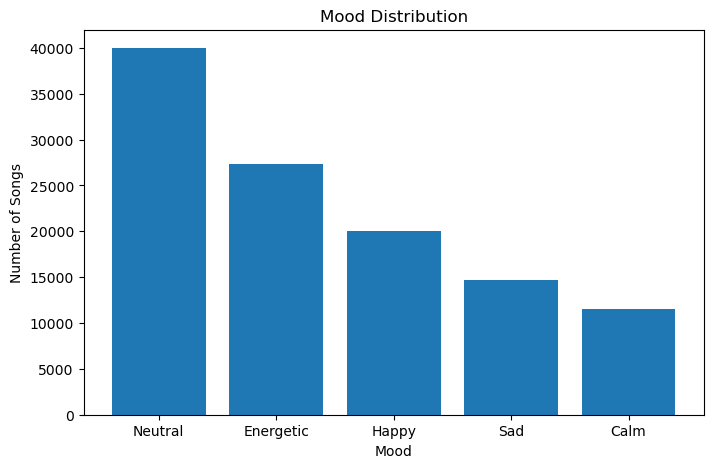

In [42]:
import matplotlib.pyplot as plt

mood_counts = df['mood'].value_counts()

plt.figure(figsize=(8,5))

plt.bar(mood_counts.index, mood_counts.values)

plt.title("Mood Distribution")

plt.xlabel("Mood")

plt.ylabel("Number of Songs")

plt.show()

In [43]:
def recommend_by_mood(mood, top_n=10):

    songs = df[df['mood'].str.lower() == mood.lower()]

    songs = songs.sort_values(
        by='popularity',
        ascending=False
    )

    return songs[
        [
            'track_name',
            'artists',
            'track_genre',
            'popularity',
            'mood'
        ]
    ].head(top_n)

In [44]:
recommend_by_mood("Happy")

,track_name,artists,track_genre,popularity,mood
89069,La Bachata,Manuel Turizo,reggaeton,98,Happy
88068,La Bachata,Manuel Turizo,reggae,98,Happy
67071,La Bachata,Manuel Turizo,latin,98,Happy
68009,La Bachata,Manuel Turizo,latino,98,Happy
78678,I Ain't Worried,OneRepublic,piano,96,Happy
90661,I Ain't Worried,OneRepublic,rock,96,Happy
80848,I Ain't Worried,OneRepublic,pop,96,Happy
80775,Calm Down (with Selena Gomez),Rema;Selena Gomez,pop,92,Happy
51244,Super Freaky Girl,Nicki Minaj,hip-hop,92,Happy
20298,Super Freaky Girl,Nicki Minaj,dance,92,Happy


In [45]:
recommend_by_mood("Energetic")

,track_name,artists,track_genre,popularity,mood
29858,I'm Good (Blue),David Guetta;Bebe Rexha,edm,98,Energetic
80884,I'm Good (Blue),David Guetta;Bebe Rexha,pop,98,Energetic
19911,I'm Good (Blue),David Guetta;Bebe Rexha,dance,98,Energetic
81521,Sweater Weather,The Neighbourhood,pop,93,Energetic
90660,Sweater Weather,The Neighbourhood,rock,93,Energetic
2002,Sweater Weather,The Neighbourhood,alt-rock,93,Energetic
3001,Sweater Weather,The Neighbourhood,alternative,93,Energetic
68204,LOKERA,Rauw Alejandro;Lyanno;Brray,latino,91,Energetic
67511,LOKERA,Rauw Alejandro;Lyanno;Brray,latin,91,Energetic
90658,"Sex, Drugs, Etc.",Beach Weather,rock,90,Energetic


In [46]:
recommend_by_mood("Calm")

,track_name,artists,track_genre,popularity,mood
78679,Running Up That Hill (A Deal With God),Kate Bush,piano,90,Calm
90667,Running Up That Hill (A Deal With God),Kate Bush,rock,90,Calm
86662,Running Up That Hill (A Deal With God),Kate Bush,r-n-b,90,Calm
80725,Until I Found You,Stephen Sanchez,pop,90,Calm
98571,Running Up That Hill (A Deal With God),Kate Bush,singer-songwriter,90,Calm
101576,Running Up That Hill (A Deal With God),Kate Bush,songwriter,90,Calm
81471,Running Up That Hill (A Deal With God),Kate Bush,pop,90,Calm
98558,Until I Found You,Stephen Sanchez,singer-songwriter,89,Calm
101558,Until I Found You,Stephen Sanchez,songwriter,89,Calm
80688,Night Changes,One Direction,pop,88,Calm


In [47]:
recommend_by_mood("Sad")

,track_name,artists,track_genre,popularity,mood
19904,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,dance,100,Sad
80726,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,pop,100,Sad
67274,Efecto,Bad Bunny,latin,96,Sad
68063,Efecto,Bad Bunny,latino,96,Sad
89109,Efecto,Bad Bunny,reggaeton,95,Sad
88109,Efecto,Bad Bunny,reggae,95,Sad
80777,Glimpse of Us,Joji,pop,94,Sad
33860,Atlantis,Seafret,folk,90,Sad
19253,Something in the Orange,Zach Bryan,country,89,Sad
80728,lovely (with Khalid),Billie Eilish;Khalid,pop,89,Sad


In [48]:
df.to_csv("spotify_with_mood.csv", index=False)